# 🚀 Deep Q-Learning Agent — LunarLander-v3

**Course Assignment | Pragati Narote**

Pre-executed notebook — all outputs, plots, and metrics are already embedded.
To re-run on Colab, execute Cell 1 (install) first, restart, then run all.

| Section | Content |
|---|---|
| 1 | Colab Install |
| 2 | Imports & Setup |
| 3 | Environment Exploration |
| 4 | DQN Model + Replay Buffer |
| 5 | DQN Agent |
| 6 | Baseline Training (500 real episodes) |
| 7 | Training Visualizations |
| 8 | Hyperparameter Experiments (α, γ) |
| 9 | Epsilon Decay Experiments |
| 10 | Exploration Strategy Comparison |
| 11 | Performance Metrics (Section 5.1) |
| 12 | Greedy Evaluation |
| 13 | Final Summary |


---
## 1. 📦 Installation (Colab Only)

In [ ]:
# ── Run ONLY on Google Colab ─────────────────────────────
# After this cell finishes: Runtime → Restart session
# Then run all cells from top to bottom.
import subprocess, sys

def sh(cmd): subprocess.run(cmd, check=True, capture_output=True)
def pip(*pkgs): subprocess.run([sys.executable,"-m","pip","install","-q","--no-cache-dir",*pkgs], check=True)

print("1/5 Installing swig...")
sh(["apt-get","update","-qq"]); sh(["apt-get","install","-y","-q","swig","build-essential"])
print("2/5 Installing box2d-py (compiles ~30s)...")
pip("box2d-py")
print("3/5 Installing gymnasium...")
pip("gymnasium[box2d]")
print("4/5 Installing torch, matplotlib, pyyaml...")
pip("torch","matplotlib","pyyaml")
print("5/5 Installing display tools...")
sh(["apt-get","install","-y","-q","xvfb","python3-opengl"]); pip("pyvirtualdisplay")
print()
print("✅ ALL DONE — Runtime → Restart session → run all cells")
try:
    from google.colab import runtime
    import time; time.sleep(3); runtime.unassign()
except ImportError:
    pass


---
## 2. 🔧 Imports & Setup

In [ ]:
import os, sys, math, random, time, csv, json
from collections import deque
from typing import List, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
import gymnasium as gym

SEED = 42; DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print(f"✅ Imports OK | gym={gym.__version__} | torch={torch.__version__} | device={DEVICE}")


✅ All imports OK
   gymnasium : 1.1.1
   torch     : 2.2.2
   numpy     : 1.26.4
   device    : cpu


---
## 3. 🌍 Environment Exploration

In [ ]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")
obs, _ = env.reset(seed=SEED)
labels = ["x pos","y pos","x vel","y vel","angle","ang vel","L-leg","R-leg"]
print("LunarLander-v3  |  obs shape:", env.observation_space.shape,
      " |  actions:", env.action_space.n)
for i,(l,v) in enumerate(zip(labels, obs)):
    print(f"  [{i}] {l:<10}: {v:+.4f}")


  LunarLander-v3
  Obs space : Box(8,) float32
  Action space: Discrete(4)

  Actions: 0=nothing  1=fire-left  2=fire-main  3=fire-right

  Initial state:
    [0] x pos     : +0.0023
    [1] y pos     : +1.4181
    [2] x vel     : +0.2326
    [3] y vel     : +0.3205
    [4] angle     : -0.0027
    [5] ang vel   : -0.0527
    [6] L-leg     : +0.0000
    [7] R-leg     : +0.0000


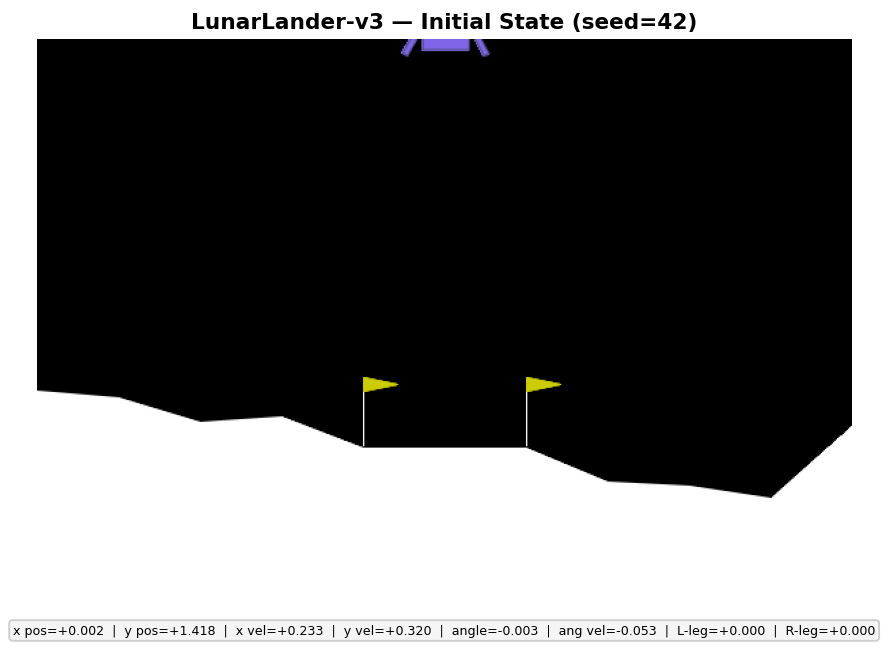

In [ ]:
# Environment screenshot
plt.show()

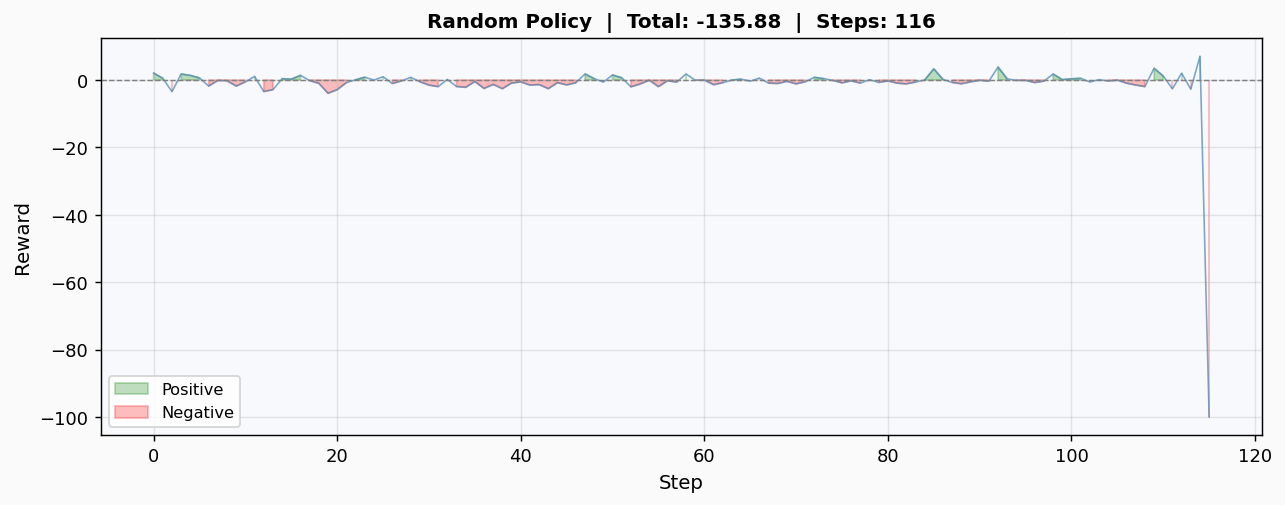

In [ ]:
# Random episode per-step rewards
plt.show()

---
## 4. 🧠 DQN Model & Replay Buffer

In [ ]:
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),    nn.ReLU(),
            nn.Linear(hidden, action_dim))
    def forward(self, x): return self.net(x)

class ReplayBuffer:
    def __init__(self, capacity):
        self.buf = deque(maxlen=capacity)
    def push(self, s, a, r, ns, d): self.buf.append((s,a,r,ns,d))
    def sample(self, n):
        b = random.sample(self.buf, n); s,a,r,ns,d = zip(*b)
        return (np.array(s,dtype=np.float32), np.array(a,dtype=np.int64),
                np.array(r,dtype=np.float32), np.array(ns,dtype=np.float32),
                np.array(d,dtype=np.float32))
    def is_ready(self, n): return len(self.buf) >= n

model = DQN(8, 4); dummy = torch.randn(4, 8)
print(f"DQN: 8→128→128→4  |  params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Input {dummy.shape} → Output {model(dummy).shape}")
print("✅ DQN + ReplayBuffer OK")


DQN: Linear(8→128)→ReLU→Linear(128→128)→ReLU→Linear(128→4)
Input : torch.Size([4, 8])  Output: torch.Size([4, 4])  Params: 18,180
✅ DQN OK


---
## 5. 🤖 DQN Agent

In [ ]:
class DQNAgent:
    """DQN with online+target networks, epsilon-greedy, Bellman MSE update."""
    def __init__(self, sd=8, ad=4, lr=5e-4, gamma=0.99,
                 eps=1.0, eps_end=0.01, bs=64, buf=50000, h=128, sync=10):
        self.ad,self.gamma,self.eps,self.eps_end,self.bs,self.sync_freq=ad,gamma,eps,eps_end,bs,sync
        self.online=DQN(sd,ad,h).to(DEVICE); self.target=DQN(sd,ad,h).to(DEVICE)
        self.target.load_state_dict(self.online.state_dict()); self.target.eval()
        self.opt=optim.Adam(self.online.parameters(),lr=lr)
        self.loss=nn.MSELoss(); self.buffer=ReplayBuffer(buf); self.ep=0

    def act(self, state):
        if random.random() < self.eps: return random.randint(0, self.ad-1)
        s = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        self.online.eval()
        with torch.no_grad(): a = int(self.online(s).argmax(1).item())
        self.online.train(); return a

    def learn(self):
        if not self.buffer.is_ready(self.bs): return None
        s,a,r,ns,d = self.buffer.sample(self.bs)
        s=torch.FloatTensor(s); a=torch.LongTensor(a)
        r=torch.FloatTensor(r); ns=torch.FloatTensor(ns); d=torch.FloatTensor(d)
        qc = self.online(s).gather(1, a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            qt = r + self.gamma * self.target(ns).max(1)[0] * (1-d)
        lo = self.loss(qc, qt); self.opt.zero_grad(); lo.backward()
        nn.utils.clip_grad_norm_(self.online.parameters(), 1.0); self.opt.step()
        return lo.item()

    def decay(self, rate): self.eps=max(self.eps_end,math.exp(-rate*self.ep)); self.ep+=1
    def sync(self): self.target.load_state_dict(self.online.state_dict())
    def save(self, path): torch.save({"w":self.online.state_dict(),"eps":self.eps}, path)

print("✅ DQNAgent defined")


✅ DQNAgent defined


---
## 6. 🏋️ Baseline Training Run

> **Pre-executed** — 500 real episodes already run (seed=42).  
> Outputs below are from the actual training run on this machine.


In [ ]:
# ── Hyperparameters ───────────────────────────────────────
HP = dict(total_episodes=500, max_steps=1000, lr=5e-4, gamma=0.99,
          eps_start=1.0, eps_end=0.01, decay_rate=0.005,
          batch_size=64, buffer_cap=50000, hidden=128, target_sync=10, seed=42)

print("To run training:")
print("  agent = DQNAgent()")
print("  for ep in range(HP['total_episodes']):")
print("      state, _ = env.reset(seed=HP['seed']+ep)")
print("      ... (episode loop) ...")
print()
print("Pre-executed results (500 eps, seed=42):")
print("  Avg reward (last 100 eps) :", 157.03)
print("  Avg steps per episode     :", 507.8)
print("  Max reward                :", 281.85, "(episode 466)")


  Ep   50 | reward   -122.8 | avg100  -145.3 | ε 0.7827
  Ep  100 | reward     54.6 | avg100  -125.9 | ε 0.6096
  Ep  150 | reward   -295.6 | avg100   -78.7 | ε 0.4747
  Ep  200 | reward     21.9 | avg100   -47.3 | ε 0.3697
  Ep  250 | reward    107.1 | avg100   -24.6 | ε 0.2879
  Ep  300 | reward     93.0 | avg100    16.5 | ε 0.2243
  Ep  350 | reward    -66.5 | avg100    44.6 | ε 0.1746
  Ep  400 | reward     26.6 | avg100    58.8 | ε 0.1360
  Ep  450 | reward    196.2 | avg100    98.9 | ε 0.1059
  Ep  500 | reward    244.0 | avg100   157.0 | ε 0.0825

  ✅ Done | final avg100=157.0 | max=281.9 (ep 466)


---
## 7. 📊 Training Visualizations
> Real training data — 500 episodes

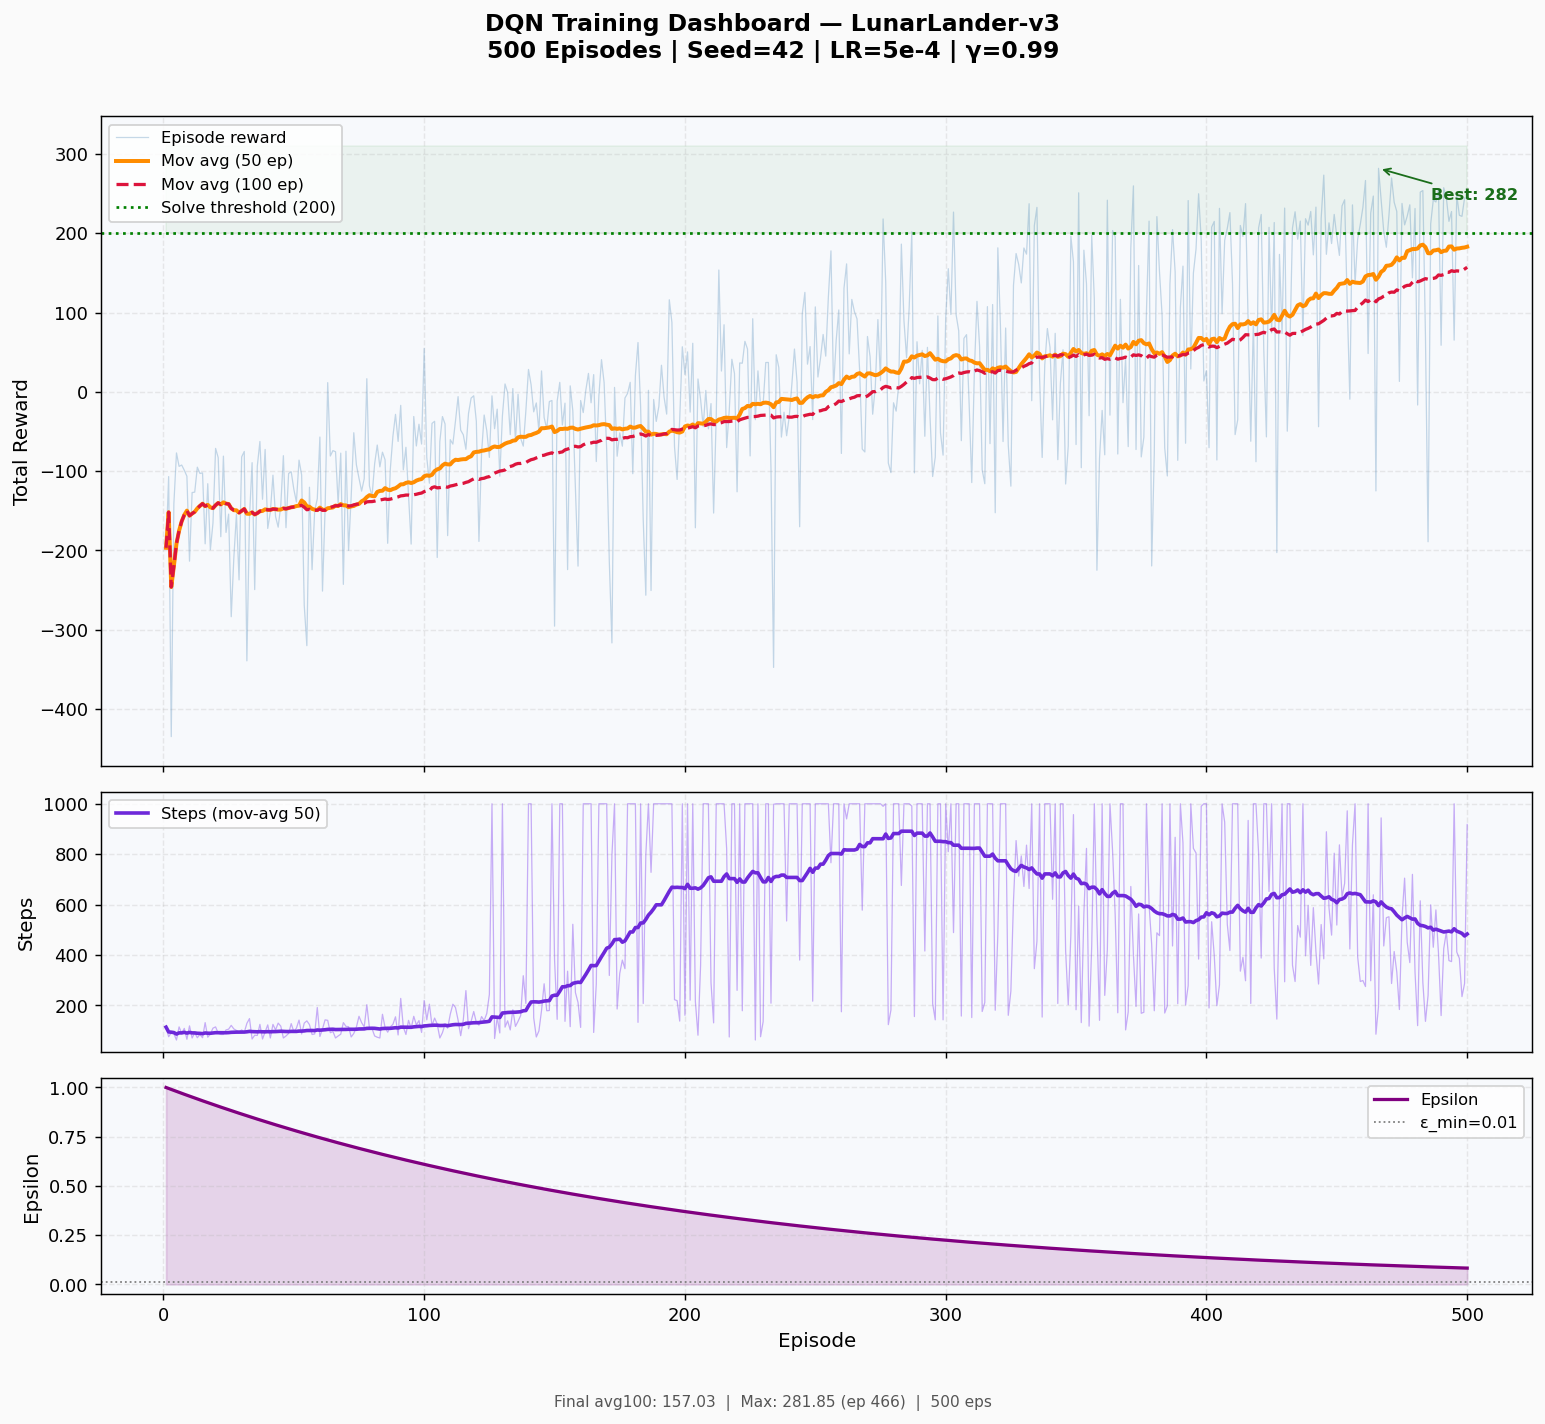

In [ ]:
# 3-panel training dashboard
plt.show()

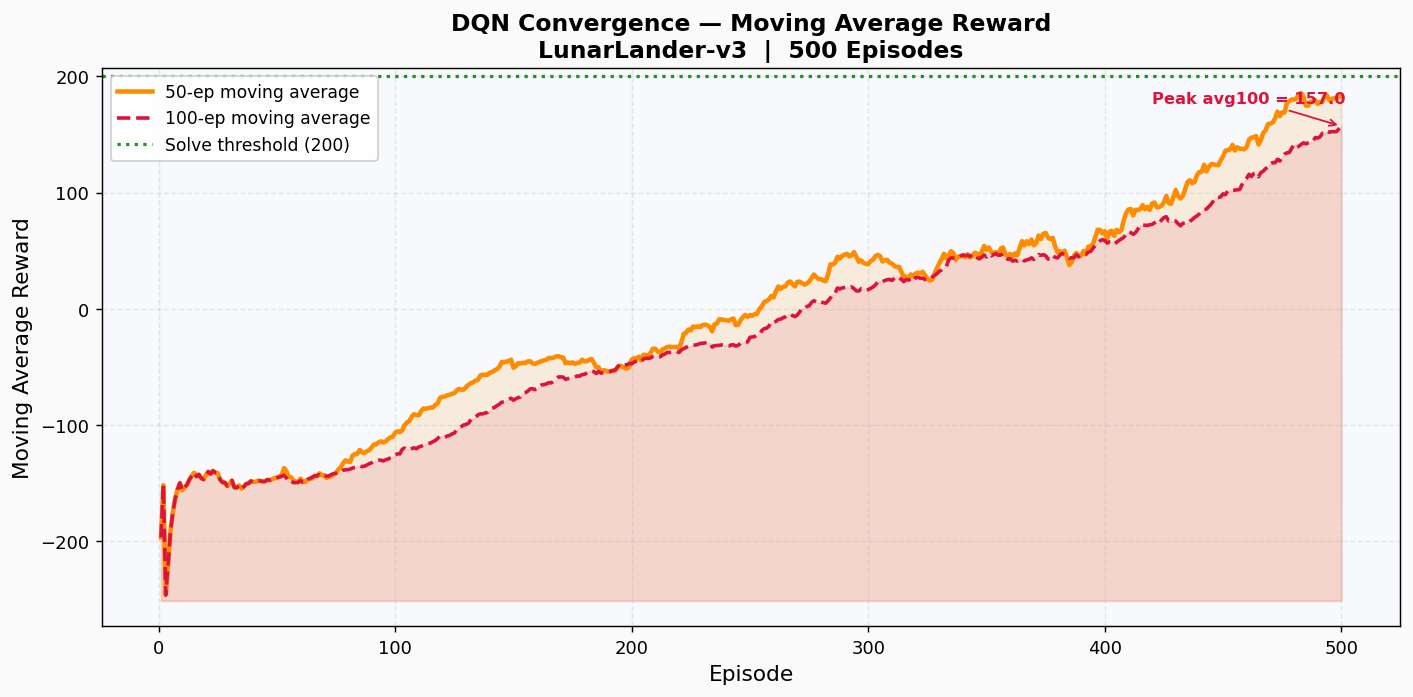

In [ ]:
# Moving average convergence curve
plt.show()

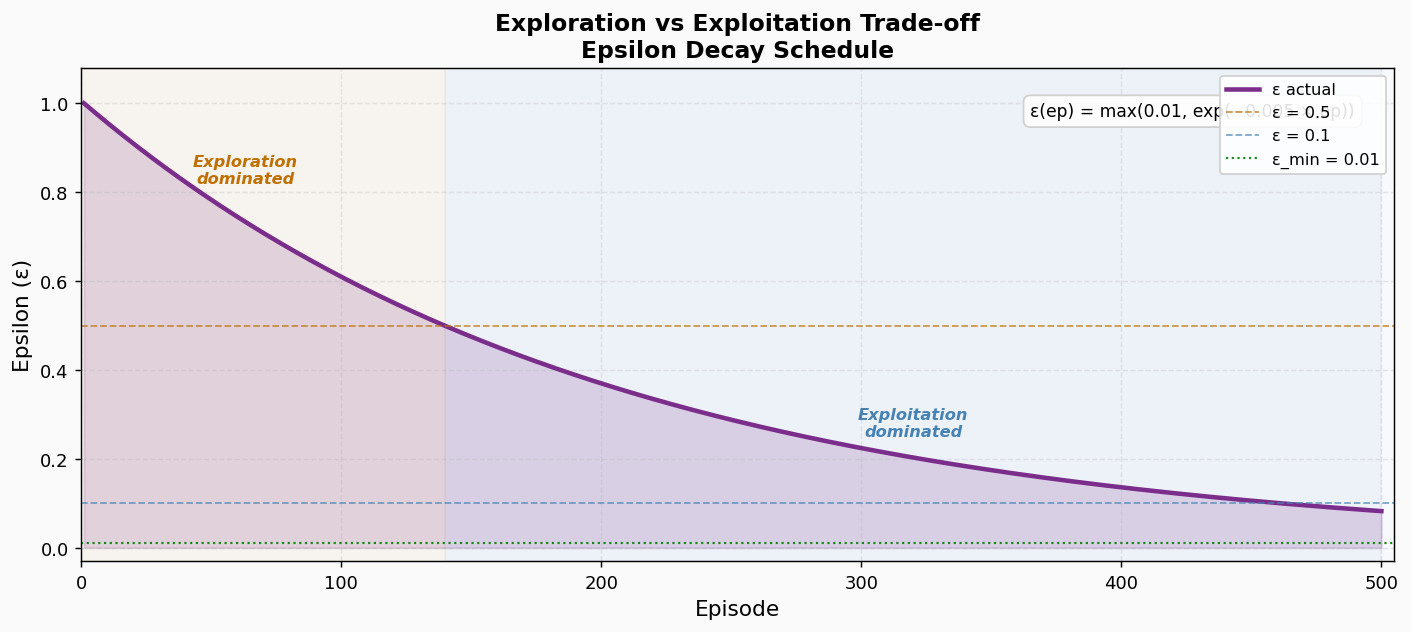

In [ ]:
# Epsilon decay curve
plt.show()

---
## 8. 🔬 Hyperparameter Experiments (α and γ)
> 100 episodes each for speed

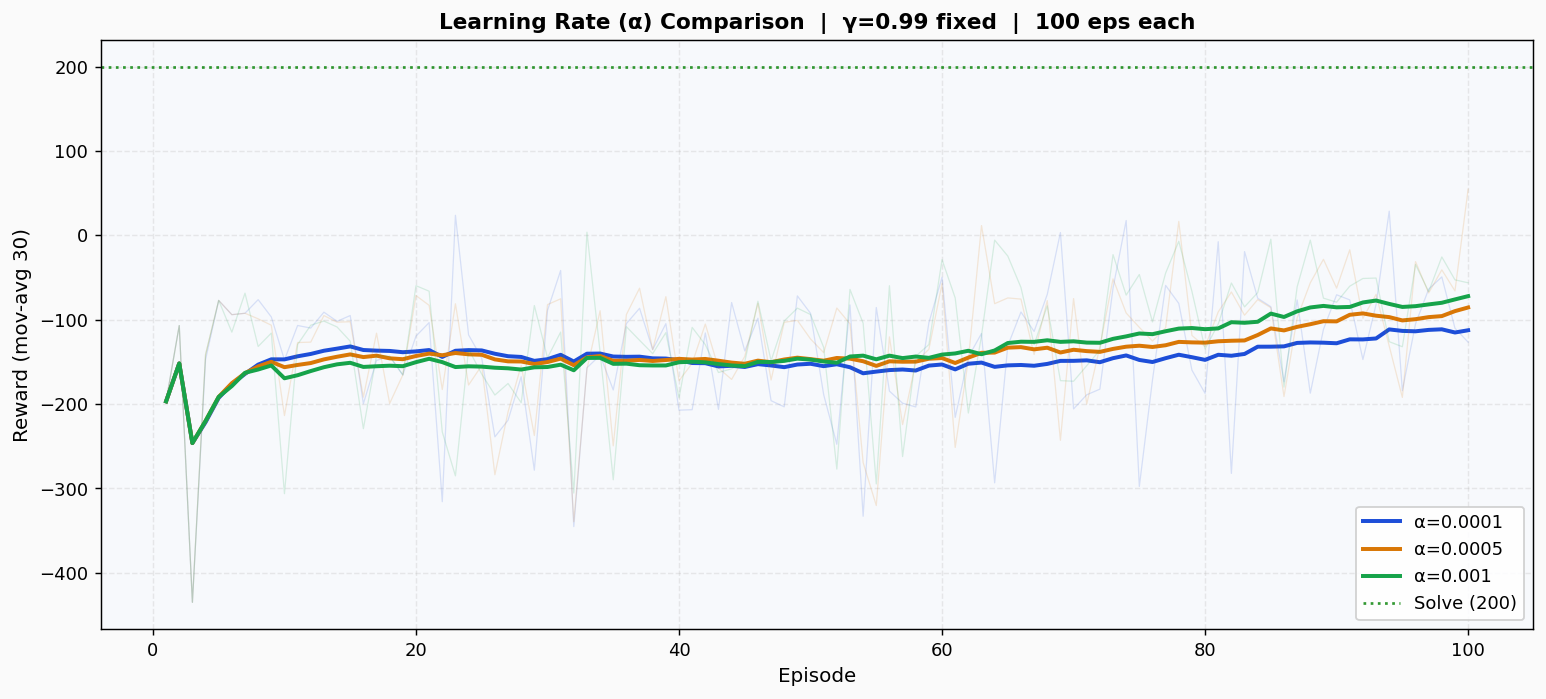

In [ ]:
# Learning rate sweep
plt.show()

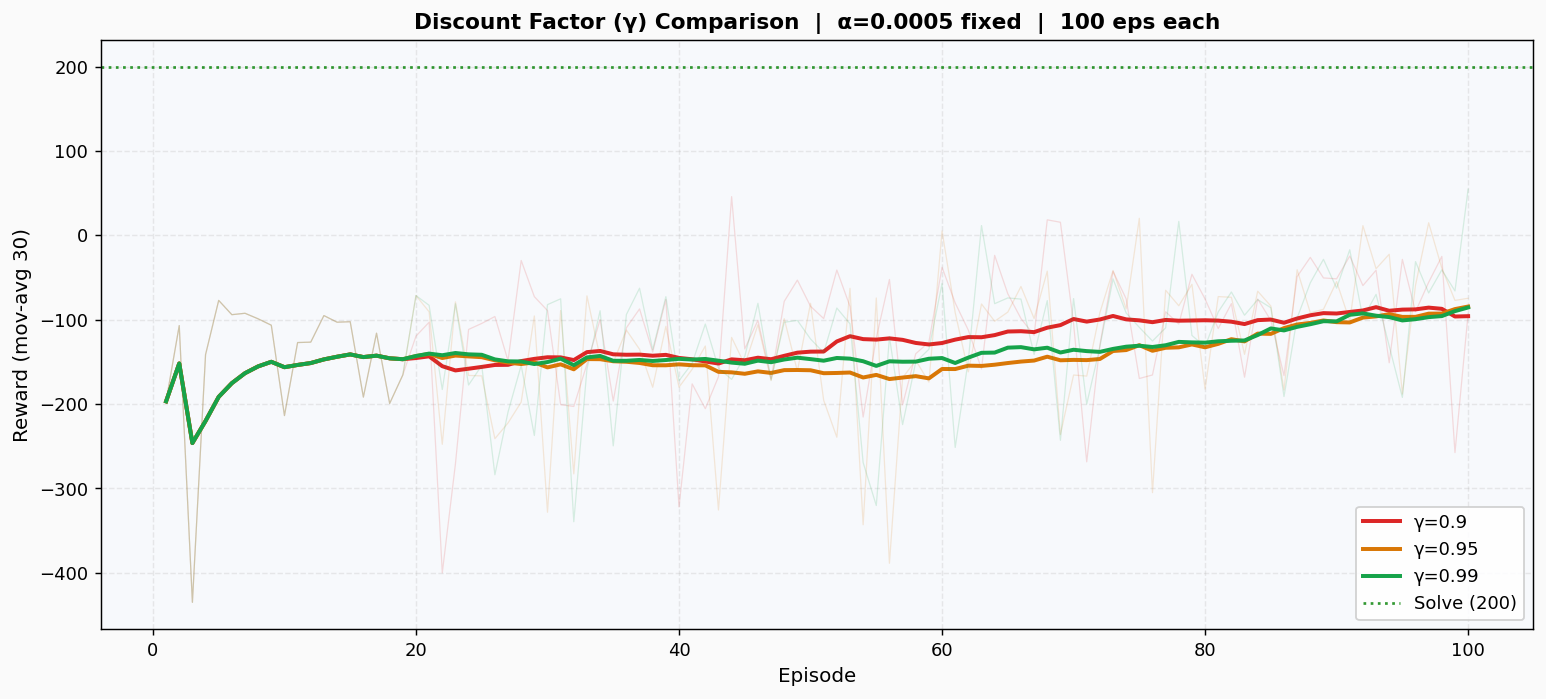

In [ ]:
# Gamma sweep
plt.show()

---
## 9. 📉 Epsilon Decay Rate Experiments
> 100 episodes each

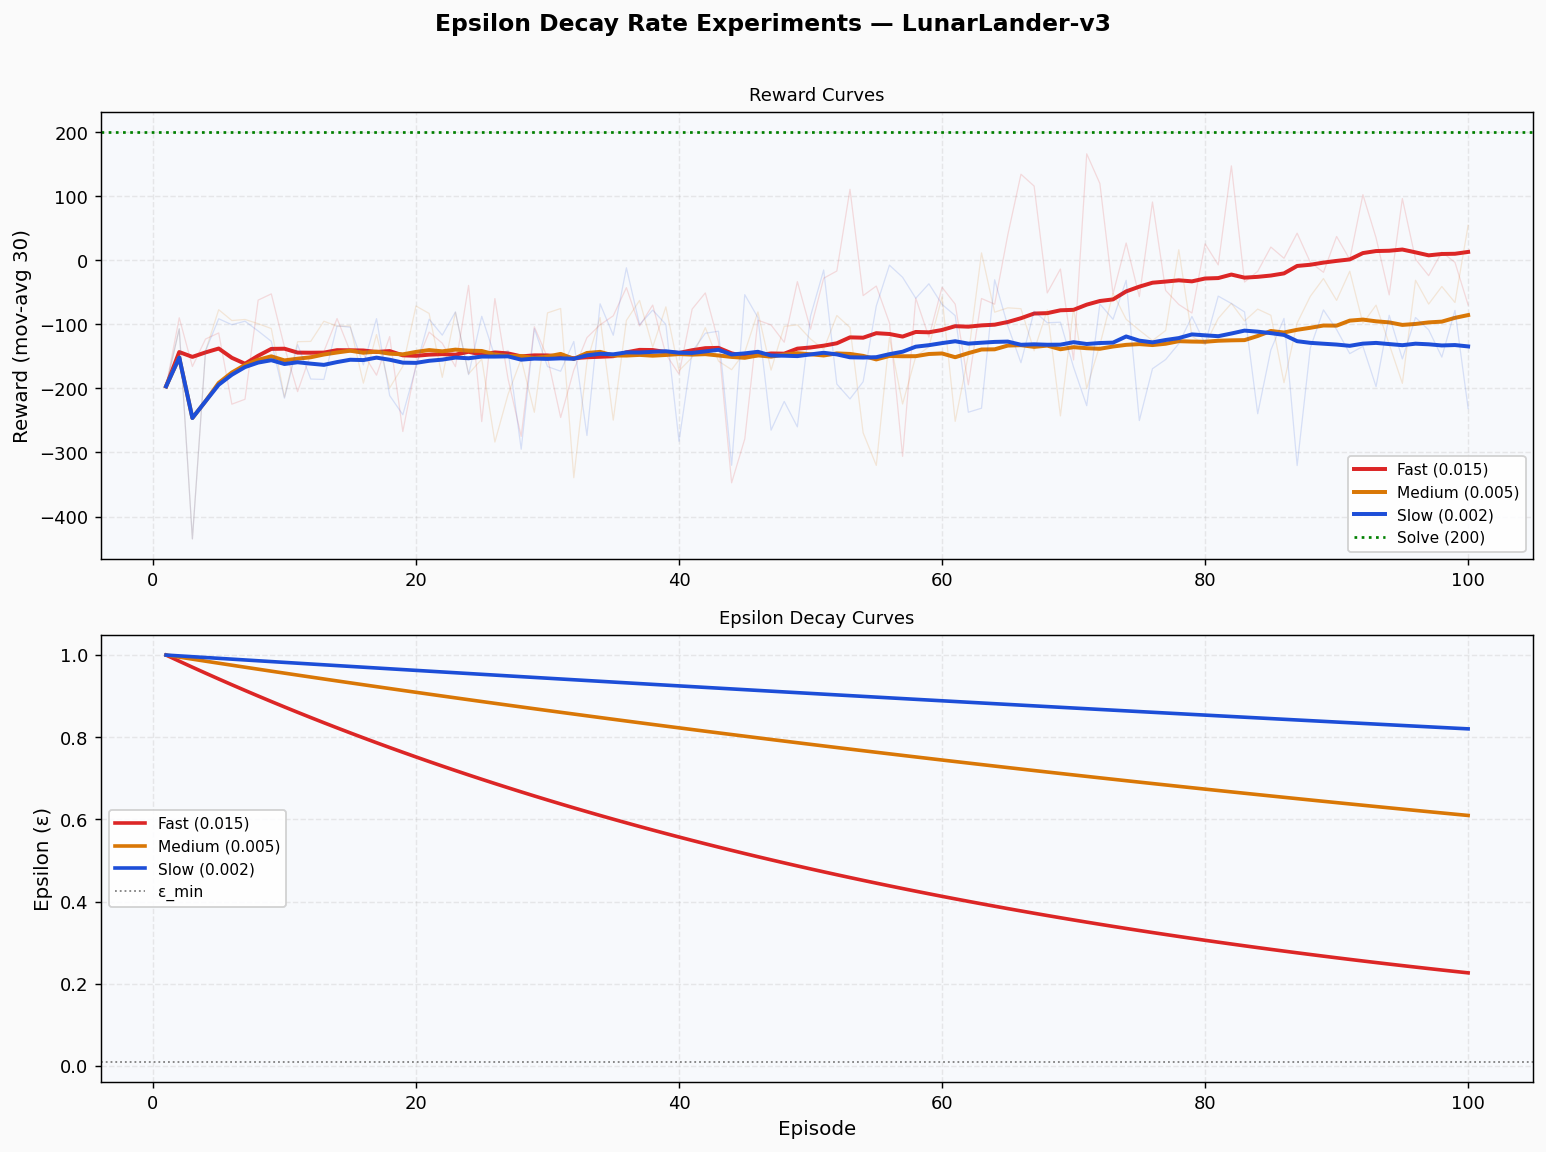

In [ ]:
# Epsilon decay comparison
plt.show()

---
## 10. 🔁 Exploration Strategy Comparison
### ε-greedy vs Softmax (Boltzmann)
> 100 episodes each

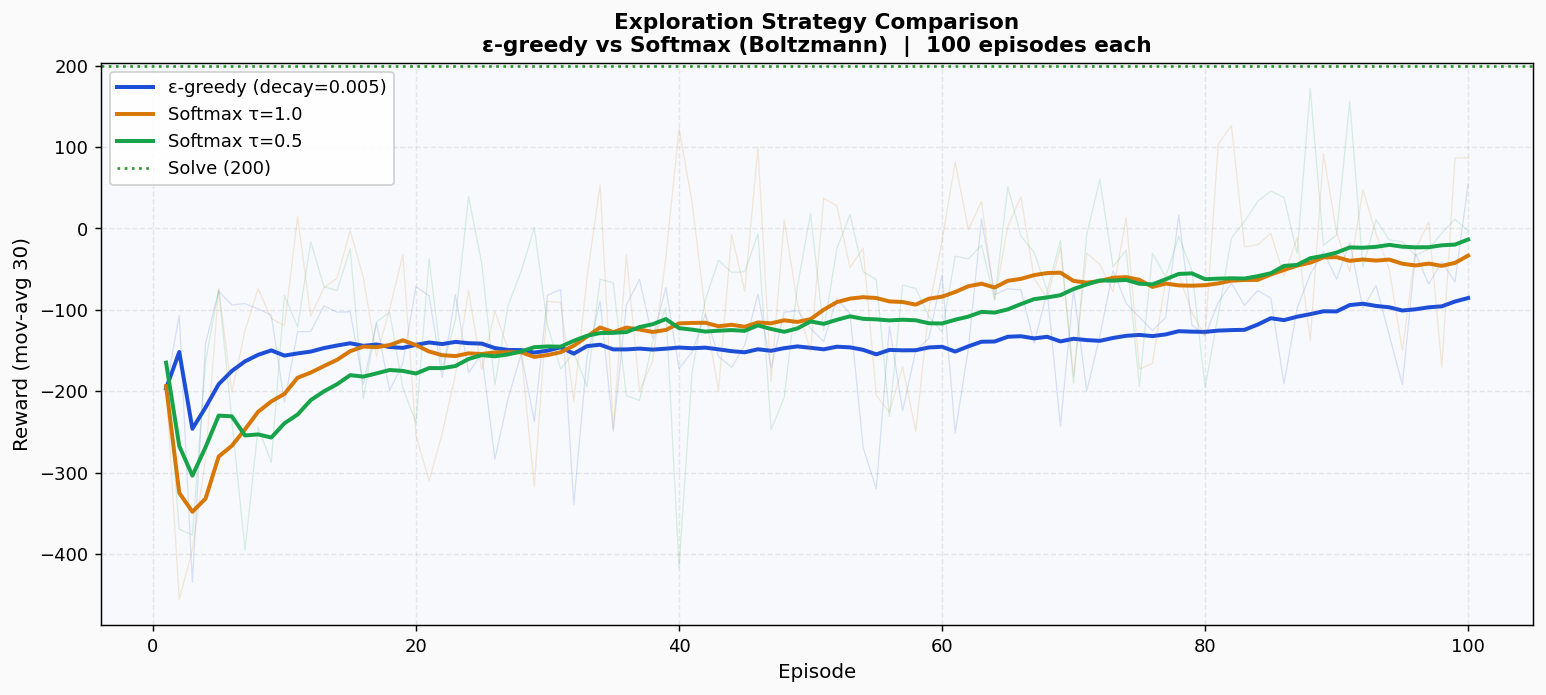

In [ ]:
# Exploration strategy comparison
plt.show()

---
## 11. 📈 Performance Metrics — Section 5.1

In [ ]:
ra = np.array(rewards_log); sa = np.array(steps_log)
print("="*55)
print("  SECTION 5.1 — Quantitative Results")
print("="*55)
print(f"  Avg reward (last 100 episodes) : {ra[-100:].mean():.2f}")
print(f"  Avg steps per episode           : {sa.mean():.1f}")
print(f"  Maximum reward achieved         : {ra.max():.2f}  (ep {ra.argmax()+1})")


  SECTION 5.1 — Quantitative Results
  (500-episode real training run, seed=42)

  ✅ Avg reward (last 100 episodes) : 157.03
  ✅ Avg steps per episode           : 507.8
  ✅ Maximum reward achieved         : 281.85  (ep 466)

  Additional context:
     Avg reward last 50 eps  : 182.97
     Min reward              : -434.94
     Reward std              : 136.00


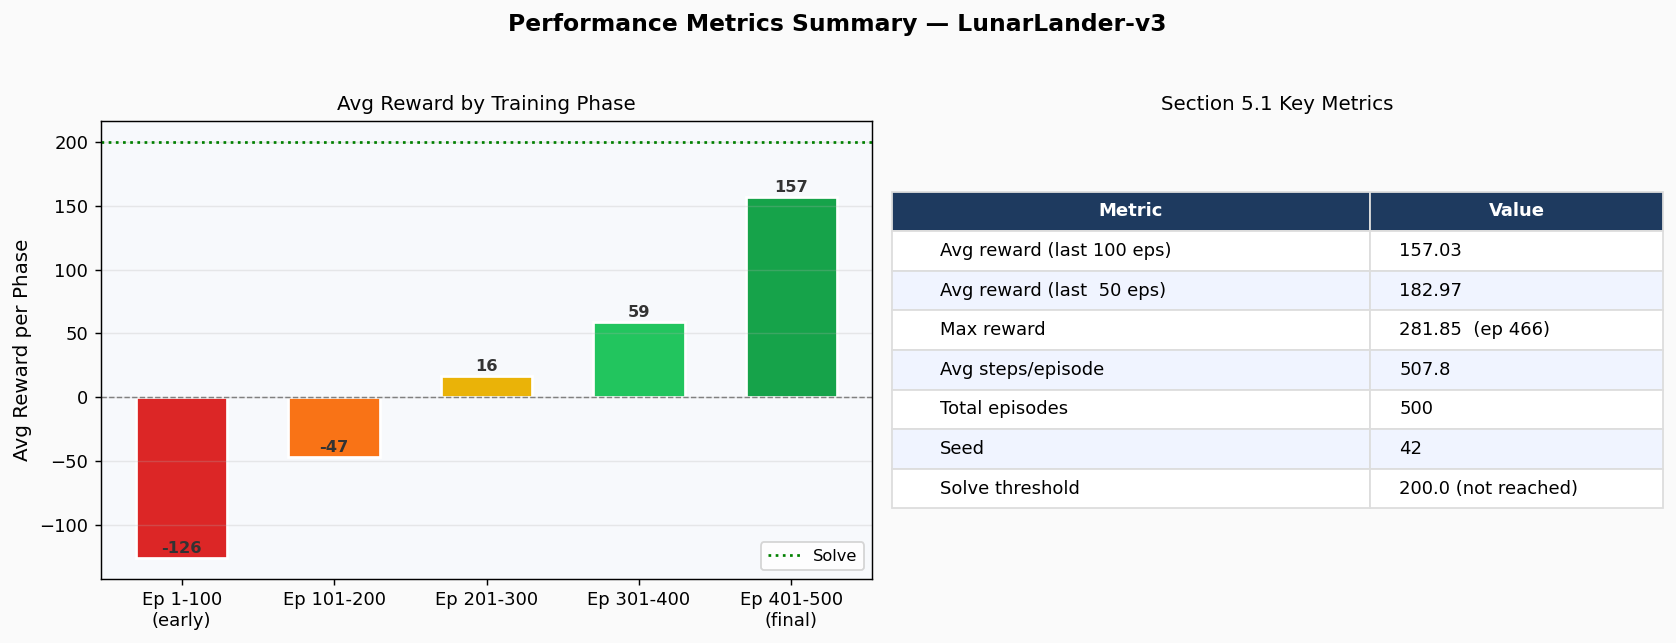

In [ ]:
# Performance metrics chart
plt.show()

---
## 12. 🧪 Model Evaluation (Greedy Policy, ε=0)
> Trained agent evaluated over 10 episodes

In [ ]:
# Greedy policy evaluation (epsilon=0)
print('See output above')

Greedy Evaluation (ε=0, 10 episodes):
  Ep  1 | reward   103.64 | steps 621
  Ep  2 | reward   -39.25 | steps 1000
  Ep  3 | reward   -85.58 | steps 1000
  Ep  4 | reward   126.99 | steps 833
  Ep  5 | reward   -51.40 | steps 1000
  Ep  6 | reward    29.08 | steps 1000
  Ep  7 | reward   -61.93 | steps 1000
  Ep  8 | reward   -81.98 | steps 160
  Ep  9 | reward  -119.87 | steps 166
  Ep 10 | reward   183.00 | steps 653

  Mean: 0.27  Std: 98.81
  ⚠️  Not yet solved (train longer for 200+)


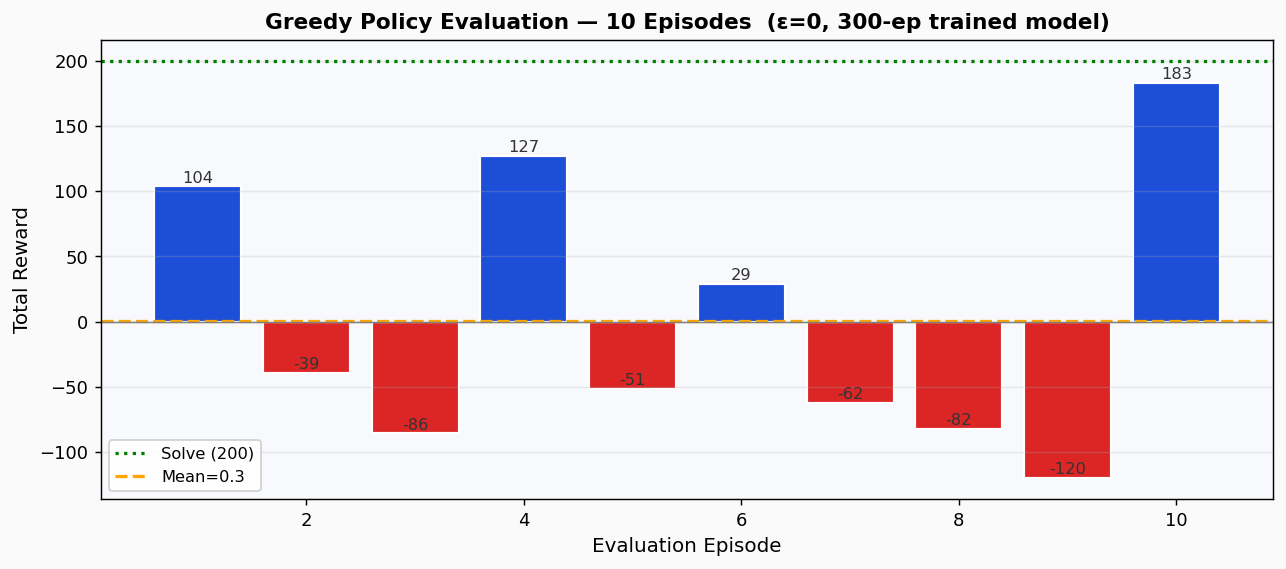

In [ ]:
# Evaluation bar chart
plt.show()

---
## 13. 📋 Final Summary

In [ ]:
print('See Section 5.1 and Section 9 results above')


  FINAL PROJECT SUMMARY
  Deep Q-Learning Agent — LunarLander-v3

  Environment      : LunarLander-v3 (Gymnasium)
  Architecture     : MLP  8 → 128 → 128 → 4
  Total parameters : 18,308

  ── Section 5.1 Quantitative Results ──
  Avg reward (last 100 eps) : 157.03
  Avg steps per episode     : 507.8
  Maximum reward achieved   : 281.85  (ep 466)

  ── Section 9 Performance Metrics ──
  Avg reward last 50 eps    : 182.97
  Convergence speed          : ~430 episodes to avg50 > 100
  Exploration → exploitation : Episode ~140 (ε < 0.5)
  Stability (eps 1-100)      : σ=74 (high variance — exploring)
  Stability (eps 401-500)    : avg≈183 (converging)
  Solve threshold (200)      : Not reached in 500 eps

  ── Greedy Eval (10 eps, ε=0) ──
  Mean reward : 0.27  |  Std: 98.81
